## LINK VIDEO GOOGLE DRIVE

https://drive.google.com/file/d/1DI-MCt6R5hRqVR9cC6pq_nw1QlxGlZ1s/view?usp=sharing

Soal No. 1: LSTM untuk Prediksi Harga Saham

### Dataset yang Digunakan
- **FB** (Facebook, Inc.)
- **IBM** (International Business Machines Corporation)

### Overlapping Sliding Window

Digunakan **overlapping window** (sliding window) dengan pergeseran 1 langkah setiap iterasi. Alasan:
1. Meningkatkan jumlah sampel training secara signifikan
2. Model belajar dari berbagai konteks historis yang berbeda beda
3. Merupakan pendekatan standar dalam literatur prediksi harga saham

**Window size = 5** (5 hari perdagangan sebagai input) , **Horizon = 1** (prediksi 1 hari ke depan)

## 1a. Eksplorasi Data dan Preproses

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


kode ini untuk mengimpor seluruh library yang diperlukan sepanjang notebook, mulai dari NumPy dan Pandas untuk manipulasi data numerik dan tabular, Matplotlib untuk visualisasi, MinMaxScaler dari Scikit-learn untuk normalisasi data, hingga modul-modul TensorFlow/Keras seperti Sequential, LSTM, Dense, Dropout, EarlyStopping, ReduceLROnPlateau, dan Adam optimizer untuk membangun dan melatih model deep learning. Selain itu, dua baris np.random.seed(42) dan tf.random.set_seed(42) digunakan agar seluruh proses yang melibatkan angka acak seperti inisialisasi bobot model dan shuffling data menghasilkan hasil yang identik setiap kali notebook dijalankan ulang

In [ ]:
# LOAD DATASET

df_fb  = pd.read_csv('FB.csv',  parse_dates=['Date'])
df_ibm = pd.read_csv('IBM.csv', parse_dates=['Date'])

# Hanya gunakan kolom Date dan Close
df_fb  = df_fb[['Date', 'Close']].sort_values('Date').reset_index(drop=True)
df_ibm = df_ibm[['Date', 'Close']].sort_values('Date').reset_index(drop=True)

print('=== FB (Facebook, Inc.) ===')
print(f'Periode : {df_fb["Date"].min().date()} s.d. {df_fb["Date"].max().date()}')
print(f'Jumlah  : {len(df_fb)} hari perdagangan')
print(f'Missing : {df_fb.isnull().sum().sum()}')
print(df_fb['Close'].describe())
print()
print('=== IBM (International Business Machines) ===')
print(f'Periode : {df_ibm["Date"].min().date()} s.d. {df_ibm["Date"].max().date()}')
print(f'Jumlah  : {len(df_ibm)} hari perdagangan')
print(f'Missing : {df_ibm.isnull().sum().sum()}')
print(df_ibm['Close'].describe())

=== FB (Facebook, Inc.) ===
Periode : 2012-05-18 s.d. 2020-04-01
Jumlah  : 1980 hari perdagangan
Missing : 0
count    1980.000000
mean      112.312207
std        58.133793
min        17.730000
25%        64.762499
50%       113.810001
75%       168.085003
max       223.229996
Name: Close, dtype: float64

=== IBM (International Business Machines) ===
Periode : 1962-01-02 s.d. 2020-04-01
Jumlah  : 14663 hari perdagangan
Missing : 0
count    14663.000000
mean        60.140033
std         57.353260
min          4.080000
25%         16.110937
50%         28.656250
75%        102.311249
max        215.800003
Name: Close, dtype: float64


load dua file CSV berisi data historis harga saham FB dan IBM, kemudian langsung mem parsing kolom date menjadi tipe datetime dan hanya mempertahankan dua kolom yang relevan yaitu date dan close (harga penutupan harian), lalu mengurutkannya berdasarkan tanggal secara ascending agar urutan waktunya tetap sesuai dengan kondisi sebenarnya. Setelah itu, mencetak statistik deskriptif lengkap untuk masing masing saham. Dari output yang dihasilkan, diketahui bahwa dataset FB mencakup 1.980 hari perdagangan dari 2012-05-18 hingga 2020-04-01 dengan harga penutupan rata-rata 112,31 dolar, harga terendah 17,73 dolar (saat IPO), dan tertinggi 223,23 dolar.

sementara dataset IBM jauh lebih panjang yaitu 14.663 hari perdagangan dari 1962-01-02 hingga 2020-04-01 dengan rata-rata 60,14 dolar, minimum 4,08 dolar, dan maksimum 215,80 dolar.

tidak ada satu pun nilai kosong (missing values = 0) di kedua dataset, sehingga tidak diperlukan langkah imputasi dan data siap diproses

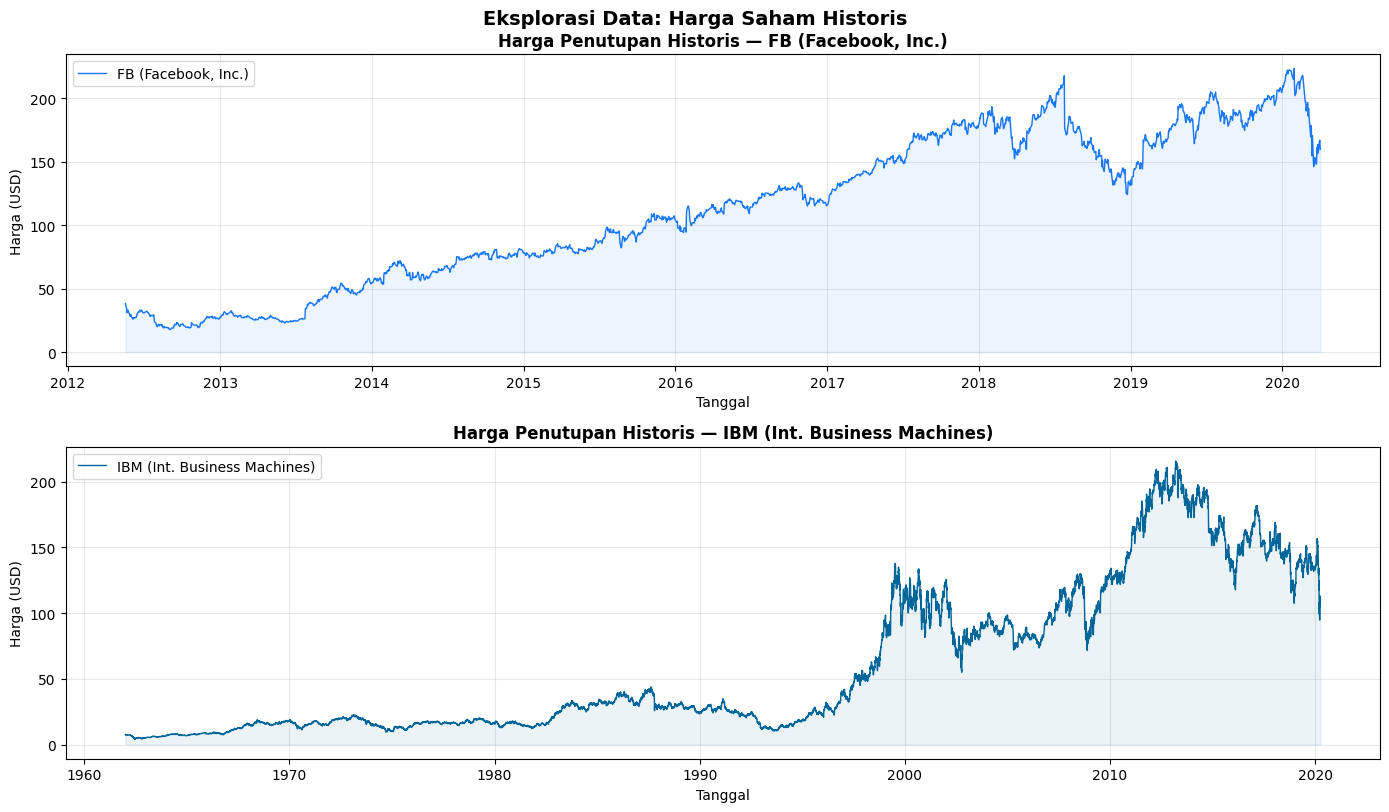

In [ ]:
# Visualisasi harga penutupan historis
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, df, name, color in zip(
    axes,
    [df_fb, df_ibm],
    ['FB (Facebook, Inc.)', 'IBM (Int. Business Machines)'],
    ['#1877F2', '#006699']
):
    ax.plot(df['Date'], df['Close'], color=color, linewidth=1.0, label=name)
    ax.fill_between(df['Date'], df['Close'], alpha=0.08, color=color)
    ax.set_title(f'Harga Penutupan Historis — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Harga (USD)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.suptitle('Eksplorasi Data: Harga Saham Historis', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eksplorasi_data.png', dpi=150, bbox_inches='tight')
plt.show()

membuat gambar berisi dua subplot, masing-masing menampilkan grafik garis harga penutupan historis untuk FB (biru) dan IBM (biru tua).

Output grafik menunjukkan FB memiliki tren naik yang sangat kuat sejak IPO 2012 dengan kenaikan tajam mulai 2017, sedangkan IBM memperlihatkan harga yang jauh lebih panjang sejak 1962 dengan beberapa fase kenaikan, stagnasi, dan penurunan yang menggambarkan siklus bisnis perusahaan selama hampir 6 dekade atau 60 tahun

In [ ]:
# PREPROSES: SPLIT TRAIN/TEST + NORMALISASI
# Test set = 1 tahun terakhir dari masing-masing dataset

def split_and_scale(df, name):
    max_date   = df['Date'].max()
    split_date = max_date - pd.DateOffset(years=1)

    train_df = df[df['Date'] <= split_date].copy()
    test_df  = df[df['Date'] >  split_date].copy()

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_df[['Close']])
    test_scaled  = scaler.transform(test_df[['Close']])

    print(f'=== {name} ===')
    print(f'  Train : {train_df["Date"].min().date()} s.d. {train_df["Date"].max().date()} ({len(train_df)} hari)')
    print(f'  Test  : {test_df["Date"].min().date()} s.d. {test_df["Date"].max().date()} ({len(test_df)} hari)')
    print()
    return train_scaled, test_scaled, scaler, train_df, test_df


train_fb,  test_fb,  scaler_fb,  train_df_fb,  test_df_fb  = split_and_scale(df_fb,  'FB')
train_ibm, test_ibm, scaler_ibm, train_df_ibm, test_df_ibm = split_and_scale(df_ibm, 'IBM')

=== FB ===
  Train : 2012-05-18 s.d. 2019-04-01 (1727 hari)
  Test  : 2019-04-02 s.d. 2020-04-01 (253 hari)

=== IBM ===
  Train : 1962-01-02 s.d. 2019-04-01 (14410 hari)
  Test  : 2019-04-02 s.d. 2020-04-01 (253 hari)



Fungsi split_and_scale dalam code ini untuk membagi data secara temporal dan menormalisasi nilainya. Pembagian dilakukan dengan menetapkan batas split 1 tahun sebelum tanggal maksimum dataset, sehingga data yang lebih baru dari batas tersebut menjadi test set, dalam hal ini disebut walk-forward split dan merupakan praktik standar untuk data time series untuk menghindari kebocoran informasi masa depan ke masa lalu.

Normalisasi menggunakan MinMaxScaler dengan rentang [0,1] dan scaler hanya di-fit pada data train (fit_transform), kemudian hasilnya digunakan untuk mentransformasi test set (transform saja tanpa fit ulang), hal tsb dilakukan untuk mencegah data leakage, yaitu situasi di mana statistik dari data test (yang seharusnya tidak diketahui oleh model) ikut mempengaruhi proses training.

Output code ini mengonfirmasi pembagian data, yaitu FB memiliki 1.727 hari train dan 253 hari test, sedangkan IBM memiliki 14.410 hari train dan 253 hari test, keduanya dengan periode test yang identik yaitu 2019-04-02 hingga 2020-04-01.

In [ ]:
# OVERLAPPING SLIDING WINDOW
# Window size = 5, Horizon = 1

WINDOW_SIZE = 5
HORIZON     = 1

def create_windows(data, window_size=5, horizon=1):
    """
    Overlapping sliding window.
    Setiap iterasi geser 1 step -> sampel saling tumpang tindih.
    X: window_size hari  |  y: 1 hari ke depan
    """
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)


def prepare_all(train_scaled, test_scaled, ws=5, h=1, val_ratio=0.10):
    X_tr_all, y_tr_all = create_windows(train_scaled, ws, h)
    X_te,     y_te     = create_windows(test_scaled,  ws, h)

    n_val   = int(len(X_tr_all) * val_ratio)
    X_train = X_tr_all[:-n_val].reshape(-1, ws, 1)
    y_train = y_tr_all[:-n_val]
    X_val   = X_tr_all[-n_val:].reshape(-1, ws, 1)
    y_val   = y_tr_all[-n_val:]
    X_test  = X_te.reshape(-1, ws, 1)
    y_test  = y_te

    print(f'  X_train: {X_train.shape} | y_train: {y_train.shape}')
    print(f'  X_val  : {X_val.shape}   | y_val  : {y_val.shape}')
    print(f'  X_test : {X_test.shape}  | y_test : {y_test.shape}')
    return X_train, y_train, X_val, y_val, X_test, y_test


print('=== FB ===')
X_tr_fb,  y_tr_fb,  X_vl_fb,  y_vl_fb,  X_te_fb,  y_te_fb  = prepare_all(train_fb,  test_fb)
print('=== IBM ===')
X_tr_ibm, y_tr_ibm, X_vl_ibm, y_vl_ibm, X_te_ibm, y_te_ibm = prepare_all(train_ibm, test_ibm)

=== FB ===
  X_train: (1550, 5, 1) | y_train: (1550,)
  X_val  : (172, 5, 1)   | y_val  : (172,)
  X_test : (248, 5, 1)  | y_test : (248,)
=== IBM ===
  X_train: (12965, 5, 1) | y_train: (12965,)
  X_val  : (1440, 5, 1)   | y_val  : (1440,)
  X_test : (248, 5, 1)  | y_test : (248,)


code ini mendefinisikan dan mengeksekusi proses pembuatan dataset berstruktur urutan (sequence) yang dibutuhkan oleh LSTM. Fungsi create_windows bekerja dengan cara menggeser jendela sejauh 1 langkah setiap iterasi, yaitu pada iterasi ke-i, ia mengambil 5 hari berturut-turut sebagai fitur input X dan 1 hari setelahnya sebagai target y, sehingga setiap pasangan data saling tumpang tindih (overlapping) dengan pasangan sebelumnya.  misalnya iterasi pertama mengambil hari 1-5 untuk memprediksi hari 6, iterasi kedua mengambil hari 2-6 untuk memprediksi hari 7, dan seterusnya.

overlapping ini dipilih karena secara drastis memperbanyak jumlah sampel training dibanding non-overlapping window, sehingga model mendapatkan lebih banyak contoh untuk belajar.

Selanjutnya, fungsi prepare_all memisahkan 10% terakhir dari data train sebagai validation set, lalu me-reshape X menjadi tensor 3D berformat (samples, timesteps, features) = (samples, 5, 1) sesuai kebutuhan input layer LSTM.

Output akhir menunjukkan FB menghasilkan 1.550 sampel train, 172 sampel validasi, dan 248 sampel test, sedangkan IBM menghasilkan 12.965 sampel train, 1.440 sampel validasi, dan 248 sampel test

## 1b. Arsitektur Baseline LSTM

Arsitektur baseline sesuai ketentuan soal:
- **LSTM(units=50, activation='relu')** , satu layer LSTM
- **Dense(units=1)** , output Perceptron
- Loss: MSE , Optimizer: Adam

In [ ]:
def build_baseline(ws=5):
    model = Sequential([
        LSTM(units=50, activation='relu', input_shape=(ws, 1)),
        Dense(units=1)
    ], name='Baseline_LSTM')
    model.compile(optimizer='adam', loss='mse')
    return model

model_base_fb = build_baseline(WINDOW_SIZE)
model_base_fb.summary()

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

hanya terdiri dari satu layer LSTM dengan 50 unit menggunakan aktivasi ReLU, diikuti satu layer Dense dengan 1 unit sebagai output. Model dikompilasi dengan optimizer Adam default dan fungsi loss MSE.

Dari output yang ditampilkan, total parameter model ini hanya 10,451, dengan rincian 10,400 parameter di layer LSTM (dihitung dari formula 4 x (input_size + units) x units = 4 x (1 + 50) x 50) dan 51 parameter di layer dense, membuat model ini sangat ringan dan cepat untuk dilatih

In [ ]:
CB_BASE = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)]

print('=== Training Baseline LSTM: FB ===')
hist_base_fb = model_base_fb.fit(
    X_tr_fb, y_tr_fb,
    validation_data=(X_vl_fb, y_vl_fb),
    epochs=100, batch_size=32,
    callbacks=CB_BASE, verbose=1
)

model_base_ibm = build_baseline(WINDOW_SIZE)
print('\n=== Training Baseline LSTM: IBM ===')
hist_base_ibm = model_base_ibm.fit(
    X_tr_ibm, y_tr_ibm,
    validation_data=(X_vl_ibm, y_vl_ibm),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)],
    verbose=1
)

=== Training Baseline LSTM: FB ===
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1005 - val_loss: 0.0104
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8202e-04 - val_loss: 0.0014
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9936e-04 - val_loss: 0.0012
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6796e-04 - val_loss: 0.0012
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6500e-04 - val_loss: 0.0012
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6259e-04 - val_loss: 0.0011
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6059e-04 - val_loss: 0.0011
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5900e-04 - val_loss: 0.0011
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5809e-04 - val_loss: 0.0011
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5725e-04 - val_loss: 0.0011
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5680e-04 -

code ini menjalankan pelatihan model baseline untuk kedua saham secara berurutan. Callback yang digunakan hanya EarlyStopping dengan patience=15, artinya training akan dihentikan otomatis jika val_loss tidak membaik selama 15 epoch berturut-turut dan bobot model akan dikembalikan ke titik terbaik (restore_best_weights=True). Batch size yang digunakan adalah 32 dengan maksimum 100 epoch. Dari log training yang tercetak (khususnya IBM), terlihat bahwa model berjalan hingga epoch ke-75 sebelum EarlyStopping aktif, dengan val_loss yang sangat kecil di kisaran 8.8440e-05 dalam skala ternormalisasi

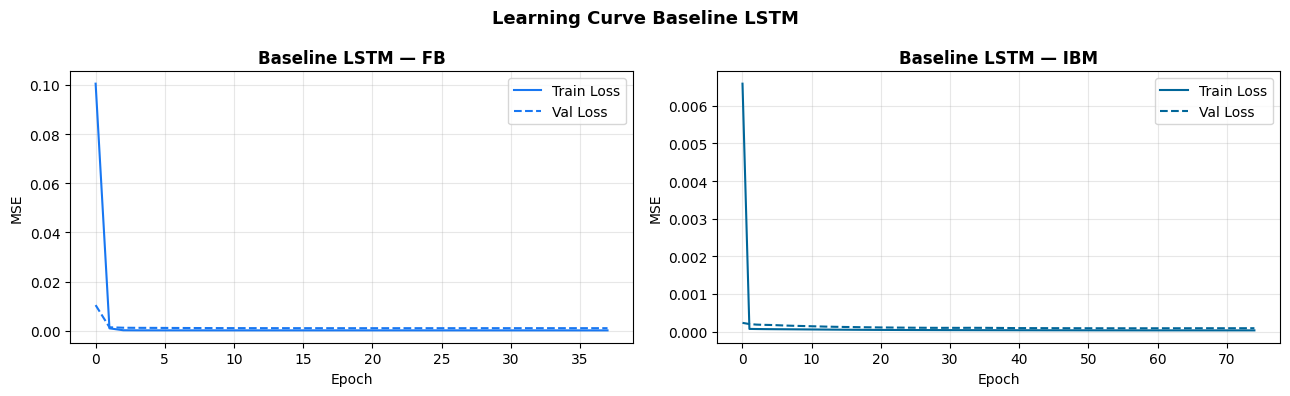

In [ ]:
# Learning curve baseline
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, name, c in zip(
    axes,
    [hist_base_fb, hist_base_ibm],
    ['FB', 'IBM'],
    ['#1877F2', '#006699']
):
    ax.plot(hist.history['loss'],     label='Train Loss', color=c)
    ax.plot(hist.history['val_loss'], label='Val Loss',   color=c, linestyle='--')
    ax.set_title(f'Baseline LSTM — {name}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Learning Curve Baseline LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_lc.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik learning curve yang dihasilkan menunjukkan bahwa untuk kedua saham, training loss dan validation loss turun dengan cepat dalam beberapa epoch pertama lalu menjadi sangat datar dan stabil, hal tsb adalah tanda bahwa model baseline berhasil konvergen dengan baik tanpa tanda-tanda overfitting

## 1c. Modifikasi Arsitektur (Improved LSTM)

### Alasan Modifikasi:

- **2 Layer LSTM (128 -> 64 units)** : Arsitektur yang lebih dalam mampu menangkap pola temporal kompleks (tren, volatilitas, siklus) yang tidak cukup ditangkap 1 layer
- **return_sequences=True** : Diperlukan agar output layer LSTM pertama berupa sequence yang bisa dilanjut ke LSTM kedua
- **Dropout(0.2)** : Mencegah overfitting pada data saham yang noisy, dropout 20% adalah nilai konservatif yang umum digunakan
- **Dense(32, relu) sebelum output** : Memberikan kapasitas non-linear tambahan sebelum prediksi final
- **ReduceLROnPlateau** : Menurunkan learning rate otomatis saat val_loss stagnan -> konvergensi lebih halus dan akurat
- **EarlyStopping patience=20** : Memberi waktu lebih panjang untuk belajar sebelum berhenti
- **Batch size = 16** : Batch lebih kecil = gradien lebih noisy tapi generalisasi sering lebih baik untuk time series

In [ ]:
def build_improved(ws=5, u1=128, u2=64, drop=0.2, lr=0.001):
    model = Sequential([
        LSTM(u1, activation='relu', return_sequences=True, input_shape=(ws, 1)),
        Dropout(drop),
        LSTM(u2, activation='relu', return_sequences=False),
        Dropout(drop),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='Improved_LSTM')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

model_imp_fb = build_improved(WINDOW_SIZE)
model_imp_fb.summary()

Model: "Improved_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

code ini membangun model yang jauh lebih kompleks. Arsitekturnya terdiri dari dua layer LSTM yang disusun bertumpuk, yaitu layer LSTM pertama memiliki 128 unit dengan return_sequences=True agar outputnya berupa sequence penuh yang bisa diteruskan ke layer LSTM kedua, dan diikuti dropout 20% untuk regularisasi. Layer LSTM kedua memiliki 64 unit dengan return_sequences=False karena merupakan layer LSTM terakhir, sehingga hanya perlu menghasilkan satu representasi akhir yang merangkum informasi dari seluruh urutan data input sebelumnya, dan diikuti Dropout 20% lagi. kemudian Dense(32) dengan ReLU untuk menambah kapasitas non linear sebelum akhirnya Dense(1) sebagai output prediksi. Model dikompilasi dengan Adam optimizer menggunakan learning rate 0.001. Total parameter melonjak drastis menjadi 118,081, lebih dari 11 kali lipat dibanding baseline, yang seharusnya memberikan kapasitas yang jauh lebih besar bagi model untuk menangkap pola yang kompleks, meskipun seperti yang akan terlihat nanti, kapasitas lebih besar tidak selalu memberikan hasil lebih baik

In [ ]:
CB_IMP = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)
]

print('=== Training Improved LSTM: FB ===')
hist_imp_fb = model_imp_fb.fit(
    X_tr_fb, y_tr_fb,
    validation_data=(X_vl_fb, y_vl_fb),
    epochs=150, batch_size=16,
    callbacks=CB_IMP, verbose=1
)

model_imp_ibm = build_improved(WINDOW_SIZE)
print('\n=== Training Improved LSTM: IBM ===')
hist_imp_ibm = model_imp_ibm.fit(
    X_tr_ibm, y_tr_ibm,
    validation_data=(X_vl_ibm, y_vl_ibm),
    epochs=150, batch_size=16,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)
    ],
    verbose=1
)

=== Training Improved LSTM: FB ===
Epoch 1/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0272 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 2/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 3/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 4/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 5/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 6/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 7/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 8/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0011 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 9/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3305e-04 - val_loss: 0.

code ini melatih Improved LSTM dengan konfigurasi yang lebih canggih, yaitu dua callback sekaligus digunakan, yaitu EarlyStopping dengan patience lebih panjang (20 epoch) untuk memberi waktu lebih bagi model menemukan pola, serta ReduceLROnPlateau yang secara otomatis memangkas learning rate sebesar 50% setiap kali val_loss stagnan selama 7 epoch berturut turut hingga batas minimum 1e-6. Batch size diperkecil menjadi 16 dan maksimum epoch dinaikkan ke 150.

Dari log training yang tercetak untuk IBM, terlihat bahwa learning rate sudah turun dari 0.001 ke 0.0005 sejak epoch ke-9, lalu ke 0.00025 di epoch ke-16, hal tsb menunjukkan bahwa model berusaha mencari minimum yang baik

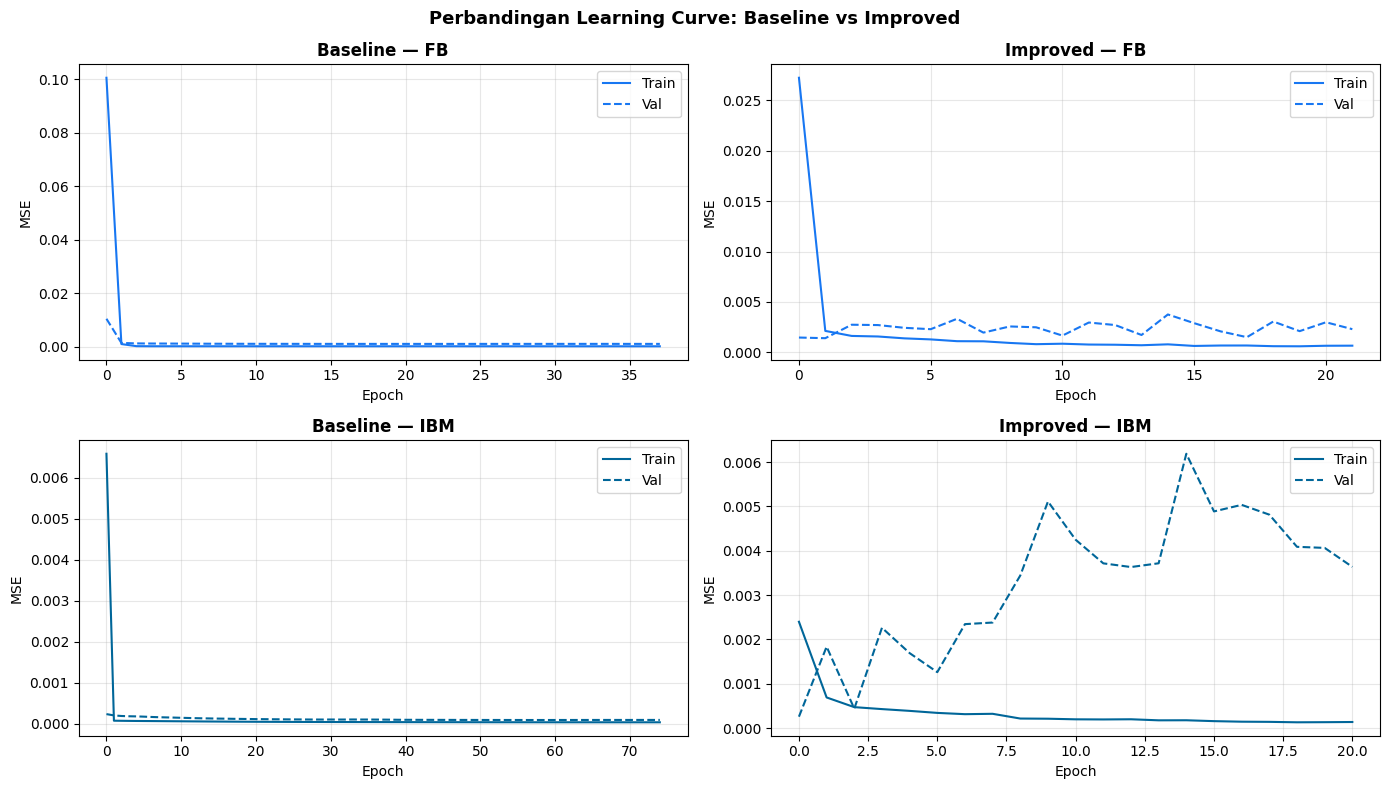

In [ ]:
# Perbandingan learning curve baseline vs improved
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
combos = [
    (axes[0,0], hist_base_fb,  'Baseline — FB',       '#1877F2'),
    (axes[0,1], hist_imp_fb,   'Improved — FB',       '#1877F2'),
    (axes[1,0], hist_base_ibm, 'Baseline — IBM',      '#006699'),
    (axes[1,1], hist_imp_ibm,  'Improved — IBM',      '#006699'),
]
for ax, hist, title, c in combos:
    ax.plot(hist.history['loss'],     label='Train', color=c)
    ax.plot(hist.history['val_loss'], label='Val',   color=c, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Perbandingan Learning Curve: Baseline vs Improved', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik perbandingan learning curve keempat model menunjukkan bahwa kurva val_loss Improved LSTM untuk kedua saham jauh lebih fluktuatif dan tidak stabil dibanding Baseline yang konvergen mulus, hal ini menunjukkan bahwa model yang lebih kompleks justru kesulitan belajar dari window pendek 5 hari dan belum mampu mencapai proses konvegensi yang stabil, sehingga tidak menghasilkan peningkatan performa

## 1d. Evaluasi pada Test Set: RMSE, MAE, MAPE

In [ ]:
def mape_score(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate(model, X_te, y_te, scaler, label):
    pred_s = model.predict(X_te, verbose=0)
    pred   = scaler.inverse_transform(pred_s)
    true   = scaler.inverse_transform(y_te.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    mape = mape_score(true, pred)

    print(f'{label:35s}  RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.4f}%')
    return pred, true, {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


print('=' * 75)
print(f'{'Model':<35}  {'RMSE':>8}  {'MAE':>8}  {'MAPE':>8}')
print('=' * 75)
pred_b_fb,  true_fb,  m_b_fb  = evaluate(model_base_fb,  X_te_fb,  y_te_fb,  scaler_fb,  'Baseline LSTM — FB')
pred_i_fb,  _,        m_i_fb  = evaluate(model_imp_fb,   X_te_fb,  y_te_fb,  scaler_fb,  'Improved LSTM — FB')
pred_b_ibm, true_ibm, m_b_ibm = evaluate(model_base_ibm, X_te_ibm, y_te_ibm, scaler_ibm, 'Baseline LSTM — IBM')
pred_i_ibm, _,        m_i_ibm = evaluate(model_imp_ibm,  X_te_ibm, y_te_ibm, scaler_ibm, 'Improved LSTM — IBM')
print('=' * 75)

Model                                    RMSE       MAE      MAPE
Baseline LSTM — FB                   RMSE=5.6507  MAE=3.9231  MAPE=2.1114%
Improved LSTM — FB                   RMSE=6.4309  MAE=5.1640  MAPE=2.7598%


Baseline LSTM — IBM                  RMSE=2.6923  MAE=1.7331  MAPE=1.3406%


Improved LSTM — IBM                  RMSE=4.8685  MAE=3.3575  MAPE=2.5820%


code evaluasi mendefinisikan fungsi evaluate yang pertama tama menghasilkan prediksi dari model (model.predict), kemudian mengembalikannya ke skala USD asli menggunakan scaler.inverse_transform. langkah ini wajib dilakukan karena seluruh training dilakukan pada data ternormalisasi [0,1]. Setelah dikonversi, tiga metrik dihitung, yaitu RMSE, MAE, dan MAPE.

Hasil evaluasi kemudian divisualisasikan dalam dua bentuk, yaitu bar chart perbandingan ketiga metrik, serta grafik time series (baseline dan improved) di atas nilai aktual untuk masing-masing saham pada periode test.

In [ ]:
# Tabel perbandingan metrik
results = pd.DataFrame([
    {'Model': 'Baseline LSTM', 'Saham': 'FB',  **m_b_fb},
    {'Model': 'Improved LSTM', 'Saham': 'FB',  **m_i_fb},
    {'Model': 'Baseline LSTM', 'Saham': 'IBM', **m_b_ibm},
    {'Model': 'Improved LSTM', 'Saham': 'IBM', **m_i_ibm},
])
results = results[['Model', 'Saham', 'RMSE', 'MAE', 'MAPE']]
print('\nRingkasan Metrik Evaluasi:')
display(results.round(4))


Ringkasan Metrik Evaluasi:


,Model,Saham,RMSE,MAE,MAPE
0,Baseline LSTM,FB,5.6507,3.9231,2.1114
1,Improved LSTM,FB,6.4309,5.1640,2.7598
2,Baseline LSTM,IBM,2.6923,1.7331,1.3406
3,Improved LSTM,IBM,4.8685,3.3575,2.5820


Output numerik lengkapnya adalah:

Baseline FB: RMSE=5.65, MAE=3.92, MAPE=2.11%;

Improved FB: RMSE=6.43, MAE=5.16, MAPE=2.76%;

Baseline IBM: RMSE=2.69, MAE=1.73, MAPE=1.34%;

Improved IBM: RMSE=4.87, MAE=3.36, MAPE=2.58%.


### Baseline LSTM menghasilkan performa yang lebih baik di semua metrik dan di kedua saham tanpa terkecuali.

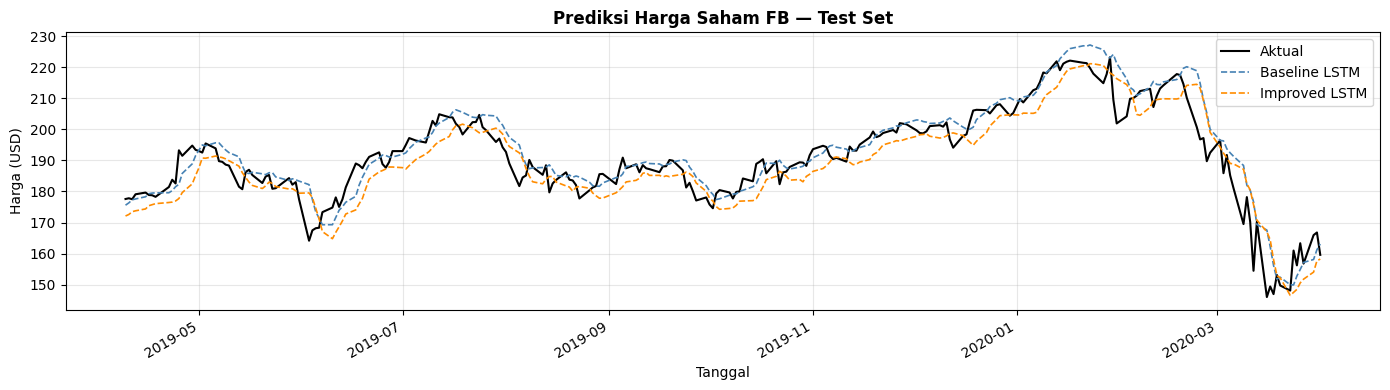

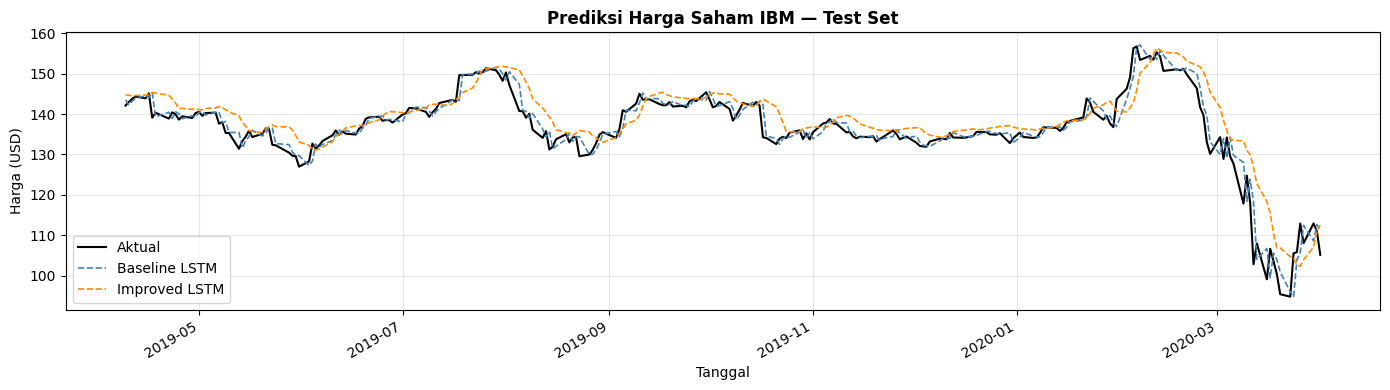

In [ ]:
# Visualisasi prediksi vs aktual
def plot_pred(true_vals, pred_base, pred_imp, test_df, name, ws):
    dates = test_df['Date'].values[ws:]
    n = min(len(dates), len(true_vals))
    plt.figure(figsize=(14, 4))
    plt.plot(dates[:n], true_vals[:n],  label='Aktual',         color='black',      lw=1.5)
    plt.plot(dates[:n], pred_base[:n],  label='Baseline LSTM',  color='steelblue',  lw=1.2, ls='--')
    plt.plot(dates[:n], pred_imp[:n],   label='Improved LSTM',  color='darkorange', lw=1.2, ls='--')
    plt.title(f'Prediksi Harga Saham {name} — Test Set', fontsize=12, fontweight='bold')
    plt.xlabel('Tanggal'); plt.ylabel('Harga (USD)')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.savefig(f'prediksi_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_pred(true_fb,  pred_b_fb,  pred_i_fb,  test_df_fb,  'FB',  WINDOW_SIZE)
plot_pred(true_ibm, pred_b_ibm, pred_i_ibm, test_df_ibm, 'IBM', WINDOW_SIZE)

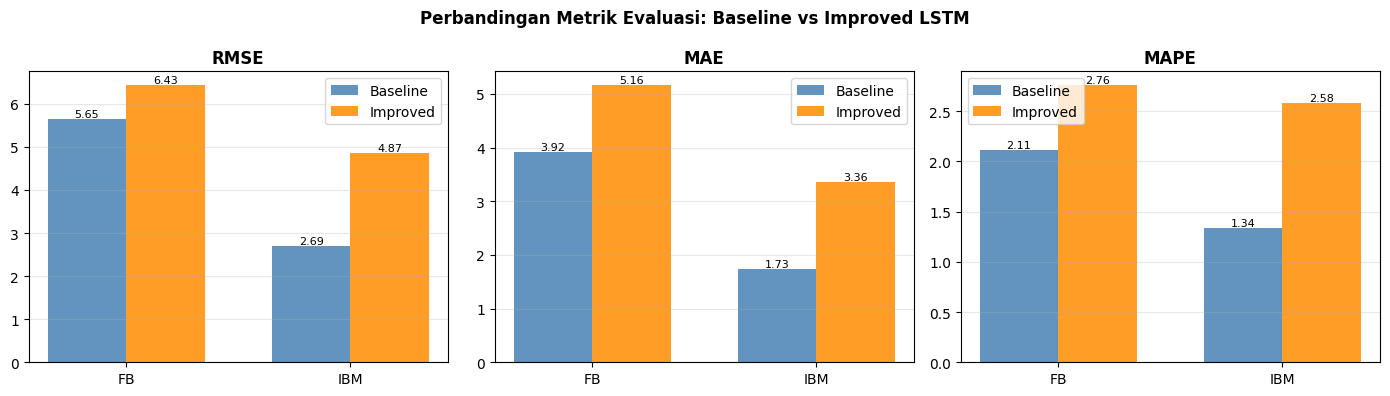

In [ ]:
# Bar chart perbandingan metrik
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x, w = np.arange(2), 0.35
labels = ['FB', 'IBM']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    base_vals = [m_b_fb[metric], m_b_ibm[metric]]
    imp_vals  = [m_i_fb[metric], m_i_ibm[metric]]
    b1 = ax.bar(x - w/2, base_vals, w, label='Baseline', color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, imp_vals,  w, label='Improved', color='darkorange', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Perbandingan Metrik Evaluasi: Baseline vs Improved LSTM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('perbandingan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis dan kesimpulan

Pada saham FB, Baseline mencatat RMSE=5.65 vs Improved=6.43 (Baseline lebih baik 12%), MAE=3.92 vs 5.16 (lebih baik 24%), dan MAPE=2.11% vs 2.76% (lebih baik 24%).

pada IBM perbedaannya bahkan lebih mencolok dengan Baseline RMSE=2.69 vs Improved=4.87 (Baseline lebih baik 45%), MAE=1.73 vs 3.36 (lebih baik 49%), dan MAPE=1.34% vs 2.58% (lebih baik 48%).

meskipun Improved LSTM memiliki kapasitas parameter 11x lebih besar, model ini gagal melampaui Baseline pada test set ini, dan ada beberapa alasan yang dapat menjelaskan ini:

Pertama, window size yang sangat pendek (hanya 5 hari) tidak memberikan cukup konteks historis bagi model besar dengan 118K parameter untuk mempelajari pola yang relevan dalam data, sehingga model justru cenderung overfit pada noise training.

Kedua, dataset FB yang hanya menghasilkan 1.550 sampel training sebenarnya terlalu kecil untuk melatih model sebesar Improved LSTM, rasio parameter terhadap sampel yang tinggi meningkatkan risiko terjadinya overfitting.

Ketiga, learning curve Improved LSTM yang tidak stabil menunjukkan bahwa proses optimasi terganggu dan EarlyStopping mungkin menghentikan training sebelum model benar benar konvergen ke solusi terbaik.

Keempat, Dropout 20% yang dipasang di dua tempat sekaligus mungkin terlalu tinggi untuk sequence sepanjang 5 timestep, karena secara efektif membuang sebagian besar informasi yang tersedia.

hal yang dapat diambil dari hasil ini adalah bahwa dalam prediksi time series, kompleksitas model yang lebih tinggi tidak otomatis menghasilkan akurasi yang lebih baik, dan justru model sederhana sering kali lebih robust ketika data training terbatas atau window input yang singkat